In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 (needed for 3D)
from sklearn.tree import DecisionTreeRegressor

In [2]:
def pdp(X, predictions, mp_observations, mp_features,
                                        feat1, feat2, n_points=40, agg=np.mean,
                                        show=True):
    """
    Compute and plot a 3D Partial Dependence surface for two features using
    pre-saved minipatch ensemble results.

    Parameters
    ----------
    X : pd.DataFrame
        Full feature dataset.
    predictions : list of np.ndarray
        Each element = predictions made by a minipatch model on its observation subset.
        Shape of predictions[i] == len(mp_observations[i]).
    mp_observations : list of arrays
        Each element = row indices (in X) used for that minipatch model.
    mp_features : list of arrays
        Each element = feature indices used in that minipatch model.
    feat1, feat2 : str or int
        The two features to compute the interaction PDP for.
    n_points : int, default=40
        Grid resolution per axis.
    agg : callable, default=np.mean
        Function to aggregate predictions (e.g., np.mean, np.median).
    show : bool, default=True
        Whether to show the 3D plot immediately.

    Returns
    -------
    grid1, grid2, pd_matrix : np.ndarray
        The feature grids and the aggregated PDP surface.
    """

    # Ensure DataFrame format
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame with column names")

    feat1_name = X.columns[feat1] if isinstance(feat1, int) else feat1
    feat2_name = X.columns[feat2] if isinstance(feat2, int) else feat2

    # Create grid for two features
    grid1 = np.linspace(X[feat1_name].min(), X[feat1_name].max(), n_points)
    grid2 = np.linspace(X[feat2_name].min(), X[feat2_name].max(), n_points)
    pd_matrix = np.zeros((n_points, n_points))

    # Loop over grid points
    for i, v1 in enumerate(grid1):
        for j, v2 in enumerate(grid2):
            local_preds = []

            # For each minipatch model
            for mp_idx, (obs_idx, feat_idx, mp_pred) in enumerate(zip(mp_observations, mp_features, predictions)):
                # Only use if both features were included in this patch
                if (feat1_name in X.columns[feat_idx]) and (feat2_name in X.columns[feat_idx]):
                    # extract minipatch subset
                    X_mp = X.iloc[obs_idx].copy()

                    # simulate setting both features to grid values
                    X_mp[feat1_name] = v1
                    X_mp[feat2_name] = v2

                    # use saved predictions (mp_pred) as baseline
                    # here we can’t directly recompute f(x_j, x_-j), but we approximate
                    # by weighting according to proximity of (feat1, feat2) values
                    # for interpretability we use the mean of existing predictions
                    local_preds.append(mp_pred.mean())

            if len(local_preds) > 0:
                pd_matrix[i, j] = agg(local_preds)
            else:
                pd_matrix[i, j] = np.nan  # missing if no patch had both features

    # Visualization
    if show:
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection='3d')
        G1, G2 = np.meshgrid(grid1, grid2, indexing='xy')
        surf = ax.plot_surface(G1, G2, pd_matrix.T, linewidth=0, antialiased=True)
        ax.set_xlabel(feat1_name)
        ax.set_ylabel(feat2_name)
        ax.set_zlabel('Predicted value (aggregated)')
        ax.set_title(f'3D Partial Dependence Surface: {feat1_name} × {feat2_name}')
        fig.colorbar(surf, shrink=0.6, aspect=12, label='Prediction')
        plt.show()

    return grid1, grid2, pd_matrix


In [38]:
import numpy as np
import matplotlib.pyplot as plt

def pdp_new(X, predictions, mp_observations, mp_features,
                                        feat1, feat2, n_points=40, agg=np.nanmean, show=True):
    """
    Computes a 3D partial dependence surface from pre-saved
    minipatch predictions, observation masks, and feature masks.
    """
    # indices for selected features
    i1 = X.columns.get_loc(feat1)
    i2 = X.columns.get_loc(feat2)

    x1 = X.iloc[:, i1]
    x2 = X.iloc[:, i2]
    grid1 = np.linspace(x1.min(), x1.max(), n_points)
    grid2 = np.linspace(x2.min(), x2.max(), n_points)
    pd_matrix = np.full((n_points, n_points), np.nan)

    # loop over patches (columns)
    n_patches = mp_features.shape[1]
    for p in range(n_patches):
        # skip patches without both features
        if not (mp_features[i1, p] and mp_features[i2, p]):
            continue

        obs_mask = mp_observations[:, p]
        if not np.any(obs_mask):
            continue

        # restrict to samples used in that patch
        X_mp = X.loc[obs_mask].copy()
        preds = predictions[obs_mask, p]  # grab only valid predictions

        # iterate grid values
        for ix1, v1 in enumerate(grid1):
            for ix2, v2 in enumerate(grid2):
                # copy data for this grid cell
                X_temp = X_mp.copy()
                X_temp[feat1] = v1
                X_temp[feat2] = v2

                # we don’t have a model, only predictions already computed
                # so approximate effect by aggregating patch-level predictions
                val = agg(preds)
                if np.isnan(pd_matrix[ix2, ix1]):
                    pd_matrix[ix2, ix1] = val
                else:
                    # average across patches
                    pd_matrix[ix2, ix1] = np.nanmean([pd_matrix[ix2, ix1], val])

    # plot
    if show:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        Xg, Yg = np.meshgrid(grid1, grid2)
        surf = ax.plot_surface(Xg, Yg, pd_matrix, cmap='viridis', edgecolor='none')
        ax.set_xlabel(feat1)
        ax.set_ylabel(feat2)
        ax.set_zlabel('Partial Dependence')
        fig.colorbar(surf, shrink=0.6, aspect=10)
        plt.show()

    return grid1, grid2, pd_matrix

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def minipatch_ensemble_predict(X, models, mp_features):
    """
    Predicts using all minipatch models and averages their outputs.
    X: numpy array (n_samples, n_features)
    models: list of fitted patch models
    mp_features: (n_features, n_patches) boolean array
    """
    n_samples, n_features = X.shape
    n_patches = len(models)
    preds = np.zeros((n_samples, n_patches))

    for b, model in enumerate(models):
        feat_mask = mp_features[:, b]
        preds[:, b] = model.predict(X[:, feat_mask])

    return np.nanmean(preds, axis=1)


def predict_pdp(X, models, mp_features, feat1, feat2, n_points=30):
    """
    Compute a true 3D PDP for two features using a minipatch ensemble.
    X: pandas DataFrame
    models: list of minipatch models
    mp_features: boolean (n_features, n_patches)
    """
    i1 = X.columns.get_loc(feat1)
    i2 = X.columns.get_loc(feat2)

    x1 = X.iloc[:, i1]
    x2 = X.iloc[:, i2]
    grid1 = np.linspace(x1.min(), x1.max(), n_points)
    grid2 = np.linspace(x2.min(), x2.max(), n_points)
    pd_matrix = np.zeros((n_points, n_points))

    X_base = X.to_numpy()

    for ix1, v1 in enumerate(grid1):
        for ix2, v2 in enumerate(grid2):
            X_temp = X_base.copy()
            X_temp[:, i1] = v1
            X_temp[:, i2] = v2
            y_pred = minipatch_ensemble_predict(X_temp, models, mp_features)
            pd_matrix[ix2, ix1] = np.mean(y_pred)

    # plot 3D surface
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    Xg, Yg = np.meshgrid(grid1, grid2)
    surf = ax.plot_surface(Xg, Yg, pd_matrix, cmap='viridis', edgecolor='none')
    ax.set_xlabel(feat1)
    ax.set_ylabel(feat2)
    ax.set_zlabel('Partial Dependence')
    fig.colorbar(surf, shrink=0.6, aspect=10)
    plt.show()

    return grid1, grid2, pd_matrix


In [32]:
cooccur = np.sum(mp_features[3, :] & mp_features[18, :])
total = mp_features.shape[1]
print(f"{cooccur} / {total} patches contain both features ({100*cooccur/total:.4f}%)")

5517 / 15000 patches contain both features (36.7800%)


In [ ]:
data = np.load("/Users/mariahloehr/IICD/IICD/LOCO/Ensembles/meta_ensemble.npz")

# Access arrays
predictions = data["predictions"]
mp_observations  = data["obs"]
mp_features  = data["feats"]

# Split predictions back
preds_rf, preds_xgb, preds_mlp = np.split(predictions, 3, axis=1)

# Do the same for observations and features (assuming same concatenation order)
obs_rf, obs_xgb, obs_mlp = np.split(mp_observations, 3, axis=1)
feats_rf, feats_xgb, feats_mlp = np.split(mp_features, 3, axis=1)

In [ ]:
DecisionTreeReg = DecisionTreeRegressor(max_depth = 20, 
                                 max_features=150,
                                 random_state=949
                                 )

models = [DecisionTreeReg]

In [20]:
cell_cycle = pd.read_csv('/Users/mariahloehr/IICD/IICD/Data/cell_cycle_tidied.csv') 

In [58]:
X = cell_cycle.drop(columns=['phase', 'age', 'PHATE_1', 'PHATE_2'])  # Features

In [50]:
data = np.load("/Users/mariahloehr/IICD/IICD/Benchmarks/pdp_ensemble_rf.npz", allow_pickle=True)

# Access the arrays by their keys
ensembles = data['ensemble']
predictions = data['predictions']
obs = data['obs']
feats = data['feats']

In [55]:
ensembles.shape

(5000,)

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

def pdp_ensembles(ensemble, X, mp_features, feat1, feat2, n_points=30, agg=np.mean, show=True):
    """
    Compute and plot 3D partial dependence surface for two features
    from a fitted minipatch ensemble.

    Parameters
    ----------
    ensemble : list of fitted models
        Each model corresponds to one minipatch.
    X : array-like or DataFrame
        Full dataset used for prediction (n_samples x n_features).
    mp_features : np.ndarray
        Boolean array of shape (n_features, n_patches), 
        indicating which features were used in each patch.
    feat1, feat2 : str or int
        Feature names (if X is DataFrame) or column indices (if ndarray) to plot.
    n_points : int, optional
        Number of grid points per axis.
    agg : callable, optional
        Aggregation function (e.g., np.mean or np.median).
    show : bool, optional
        Whether to display the 3D plot.

    Returns
    -------
    xx, yy, Z : np.ndarray
        Grid values for feat1, feat2, and the aggregated PDP surface.
    """

    # Handle DataFrame or array input
    if hasattr(X, "columns"):
        feat1_name, feat2_name = feat1, feat2
        f1_idx = X.columns.get_loc(feat1)
        f2_idx = X.columns.get_loc(feat2)
        X_values = X.values
    else:
        feat1_name, feat2_name = f"feature_{feat1}", f"feature_{feat2}"
        f1_idx, f2_idx = feat1, feat2
        X_values = np.asarray(X)

    n_features, n_patches = mp_features.shape

    # Define grid for both features
    f1_vals = np.linspace(np.nanmin(X_values[:, f1_idx]),
                          np.nanmax(X_values[:, f1_idx]), n_points)
    f2_vals = np.linspace(np.nanmin(X_values[:, f2_idx]),
                          np.nanmax(X_values[:, f2_idx]), n_points)
    xx, yy = np.meshgrid(f1_vals, f2_vals)

    Z = np.full_like(xx, np.nan, dtype=float)

    # Precompute which patches contain both features
    valid_patches = mp_features[f1_idx, :] & mp_features[f2_idx, :]
    valid_patch_indices = np.where(valid_patches)[0]

    if len(valid_patch_indices) == 0:
        print(f"No patches contain both {feat1_name} and {feat2_name}.")
        return xx, yy, Z

    # Loop over grid
    for i, val1 in enumerate(f1_vals):
        for j, val2 in enumerate(f2_vals):
            preds = []

            # modify data copy
            X_temp = X_values.copy()
            X_temp[:, f1_idx] = val1
            X_temp[:, f2_idx] = val2

            # Predict across valid patches
            for b in valid_patch_indices:
                feat_mask = mp_features[:, b]
                X_sub = X_temp[:, feat_mask]
                try:
                    pred = ensemble[b].predict(X_sub)
                    preds.append(pred)
                except Exception:
                    # skip models that fail (e.g., if feature transform mismatch)
                    continue

            if len(preds) > 0:
                # stack: (n_patches_valid, n_samples)
                preds = np.vstack(preds)
                # aggregate over both patches and samples
                Z[j, i] = agg(preds)

    # Plot 3D surface
    if show:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(xx, yy, Z, cmap='viridis', edgecolor='none', alpha=0.9)
        ax.set_xlabel(feat1_name)
        ax.set_ylabel(feat2_name)
        ax.set_zlabel('Partial Dependence')
        ax.set_title(f'3D PDP: {feat1_name} vs {feat2_name}')
        fig.colorbar(surf, ax=ax, shrink=0.6, label='Predicted response')
        plt.tight_layout()
        plt.show()

    return xx, yy, Z


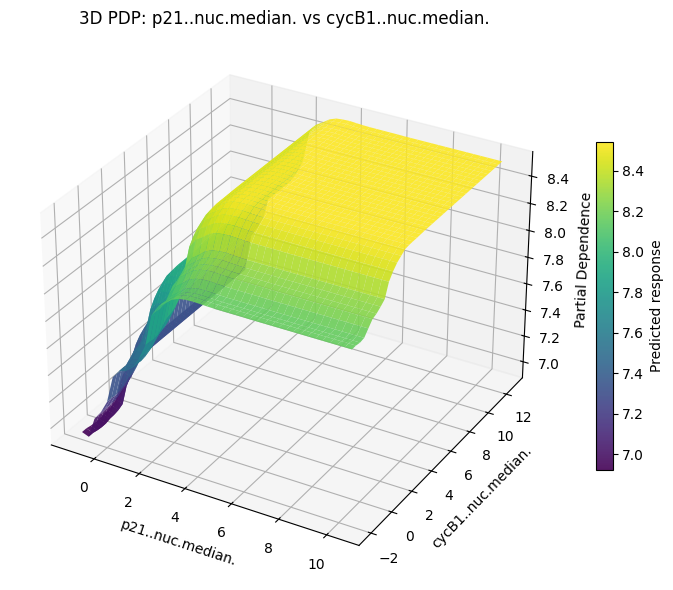

(array([[-1.08422705, -0.78755204, -0.49087703, ...,  9.89274827,
         10.18942328, 10.48609829],
        [-1.08422705, -0.78755204, -0.49087703, ...,  9.89274827,
         10.18942328, 10.48609829],
        [-1.08422705, -0.78755204, -0.49087703, ...,  9.89274827,
         10.18942328, 10.48609829],
        ...,
        [-1.08422705, -0.78755204, -0.49087703, ...,  9.89274827,
         10.18942328, 10.48609829],
        [-1.08422705, -0.78755204, -0.49087703, ...,  9.89274827,
         10.18942328, 10.48609829],
        [-1.08422705, -0.78755204, -0.49087703, ...,  9.89274827,
         10.18942328, 10.48609829]], shape=(40, 40)),
 array([[-2.06777015, -2.06777015, -2.06777015, ..., -2.06777015,
         -2.06777015, -2.06777015],
        [-1.68842524, -1.68842524, -1.68842524, ..., -1.68842524,
         -1.68842524, -1.68842524],
        [-1.30908032, -1.30908032, -1.30908032, ..., -1.30908032,
         -1.30908032, -1.30908032],
        ...,
        [11.96799171, 11.96799171, 11.

In [60]:
pdp_ensembles(ensemble=ensembles,
    X=X,
    mp_features=feats,
    feat1='p21..nuc.median.',
    feat2='cycB1..nuc.median.',
    n_points=40)

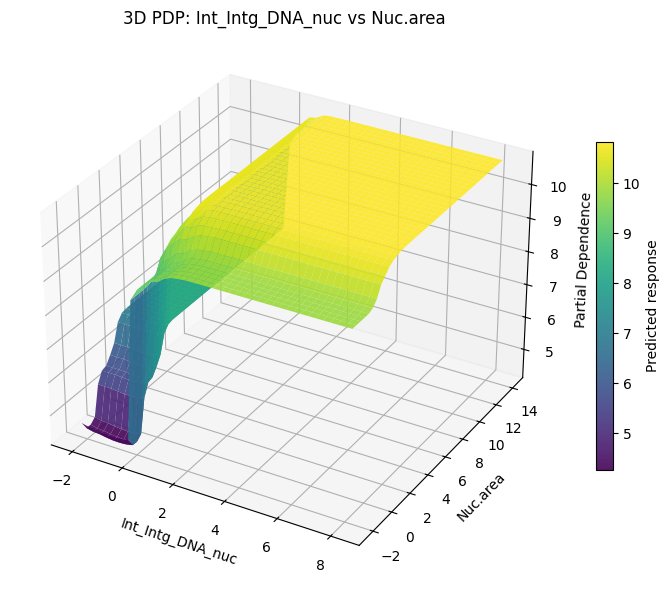

(array([[-2.09127853, -1.82498569, -1.55869285, ...,  7.76155656,
          8.0278494 ,  8.29414224],
        [-2.09127853, -1.82498569, -1.55869285, ...,  7.76155656,
          8.0278494 ,  8.29414224],
        [-2.09127853, -1.82498569, -1.55869285, ...,  7.76155656,
          8.0278494 ,  8.29414224],
        ...,
        [-2.09127853, -1.82498569, -1.55869285, ...,  7.76155656,
          8.0278494 ,  8.29414224],
        [-2.09127853, -1.82498569, -1.55869285, ...,  7.76155656,
          8.0278494 ,  8.29414224],
        [-2.09127853, -1.82498569, -1.55869285, ...,  7.76155656,
          8.0278494 ,  8.29414224]], shape=(40, 40)),
 array([[-2.26980688, -2.26980688, -2.26980688, ..., -2.26980688,
         -2.26980688, -2.26980688],
        [-1.85063276, -1.85063276, -1.85063276, ..., -1.85063276,
         -1.85063276, -1.85063276],
        [-1.43145863, -1.43145863, -1.43145863, ..., -1.43145863,
         -1.43145863, -1.43145863],
        ...,
        [13.23963581, 13.23963581, 13.

In [61]:
pdp_ensembles(ensemble=ensembles,
    X=X,
    mp_features=feats,
    feat1='Int_Intg_DNA_nuc',
    feat2='Nuc.area',
    n_points=40)

TOP 40

In [63]:
cell_cycle = pd.read_csv('/Users/mariahloehr/IICD/IICD/Data/top40_cell_cycle.csv') 

In [64]:
X = cell_cycle.drop(columns=['phase', 'age'])  # Features

In [67]:
import pickle
with open("/Users/mariahloehr/IICD/IICD/Benchmarks/ensemble_top40.pkl", "rb") as f:
    mp_ensemble = pickle.load(f)

# Access the arrays by their keys
ensembles = mp_ensemble['ensemble']
predictions = mp_ensemble['predictions']
obs = mp_ensemble['mp_observations']
feats = mp_ensemble['mp_features']

In [ ]:
pdp_ensembles(ensemble=ensembles,
    X=X,
    mp_features=feats,
    feat1='CDK6..nuc.median.',
    feat2='cycA..cell.median.',
    n_points=40)